In [39]:
import pickle
import glob
import re
from matplotlib import pyplot as plt
import numpy as np
import polars as pl

In [18]:
crate_files = glob.glob("results/*/*/stats/*.crossrate.p")
print(f"Found {len(crate_files)} coal rate files")

Found 180 coal rate files


In [22]:
regex_p = r".+Nanc-(\d+)_NpopA-(\d+)_NpopB-(\d+)_split_time-(\d+).+_seed-(\d+)/(.+?)/stats/(.+).crossrate.p"
params = ["Nanc", "NpopA", "NpopB", "split_time", "seed", "chrom", "mcmc_rep"]
re.search(regex_p, crate_files[0]).groups()

('10000', '10000', '10000', '500', '988456', '3', '3.9')

In [36]:
pickle.load(open(crate_files[0], "rb"))

{'rates': array([[[6.38776131e-05, 4.73573274e-05, 4.63815211e-05, 4.68663776e-05,
          4.60421566e-05, 4.52715956e-05, 4.67911157e-05, 5.32244977e-05,
          5.72310298e-05, 5.80709745e-05, 5.31660756e-05, 5.64640954e-05,
          5.43618195e-05, 5.00977628e-05, 4.59756502e-05, 4.23234760e-05,
                     nan,            nan,            nan,            nan,
                     nan,            nan,            nan,            nan,
                     nan],
         [2.70349780e-08, 1.06045740e-07, 2.11007055e-07, 4.94358743e-07,
          1.41761023e-06, 4.33325081e-06, 1.60556178e-05, 4.25742501e-05,
          5.56701266e-05, 5.74018074e-05, 5.34635455e-05, 5.66424086e-05,
          5.43041184e-05, 5.00226715e-05, 4.60190129e-05, 4.23000590e-05,
                     nan,            nan,            nan,            nan,
                     nan,            nan,            nan,            nan,
                     nan]],
 
        [[2.70349780e-08, 1.06045740e-07, 2.11

In [41]:
import polars as pl

regex_p = r".+Nanc-(\d+)_NpopA-(\d+)_NpopB-(\d+)_split_time-(\d+).+_seed-(\d+)/(.+?)/stats/(.+).crossrate.p"
params = ["Nanc", "NpopA", "NpopB", "split_time", "seed", "chrom", "mcmc_rep"]

data = []
for file in crate_files:
    match = re.search(regex_p, file)
    if match:
        groups = match.groups()
        row = {
            "filename": file,
            **dict(zip(params, groups))
        }
        data.append(row)

df = pl.DataFrame(data)
df = df.with_columns([
    pl.col("Nanc").cast(pl.Int32),
    pl.col("NpopA").cast(pl.Int32),
    pl.col("NpopB").cast(pl.Int32),
    pl.col("split_time").cast(pl.Int32),
    pl.col("seed").cast(pl.Int32),
    pl.col("chrom").cast(pl.Int32)
])

print(df)

shape: (180, 8)
┌─────────────────────────────────┬───────┬───────┬───────┬────────────┬────────┬───────┬──────────┐
│ filename                        ┆ Nanc  ┆ NpopA ┆ NpopB ┆ split_time ┆ seed   ┆ chrom ┆ mcmc_rep │
│ ---                             ┆ ---   ┆ ---   ┆ ---   ┆ ---        ┆ ---    ┆ ---   ┆ ---      │
│ str                             ┆ i32   ┆ i32   ┆ i32   ┆ i32        ┆ i32    ┆ i32   ┆ str      │
╞═════════════════════════════════╪═══════╪═══════╪═══════╪════════════╪════════╪═══════╪══════════╡
│ results/Nanc-10000_NpopA-10000… ┆ 10000 ┆ 10000 ┆ 10000 ┆ 500        ┆ 988456 ┆ 3     ┆ 3.9      │
│ results/Nanc-10000_NpopA-10000… ┆ 10000 ┆ 10000 ┆ 10000 ┆ 500        ┆ 988456 ┆ 3     ┆ 3.0      │
│ results/Nanc-10000_NpopA-10000… ┆ 10000 ┆ 10000 ┆ 10000 ┆ 500        ┆ 988456 ┆ 3     ┆ 3.5      │
│ results/Nanc-10000_NpopA-10000… ┆ 10000 ┆ 10000 ┆ 10000 ┆ 500        ┆ 988456 ┆ 3     ┆ 3.7      │
│ results/Nanc-10000_NpopA-10000… ┆ 10000 ┆ 10000 ┆ 10000 ┆ 500        ┆ 98

In [45]:
df.group_by("split_time","Nanc","NpopA","NpopB").agg(pl.count()).sort("split_time")

/tmp/ipykernel_3423214/1818512920.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  df.group_by("split_time","Nanc","NpopA","NpopB").agg(pl.count()).sort("split_time")


split_time,Nanc,NpopA,NpopB,count
i32,i32,i32,i32,u32
50,10000,10000,1000,60
275,10000,10000,10000,60
500,10000,10000,10000,60


/tmp/ipykernel_3423214/1549765173.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  groups = df.group_by("split_time", "Nanc", "NpopA", "NpopB").agg(pl.count()).sort("split_time")


shape: (3, 5)
┌────────────┬───────┬───────┬───────┬───────┐
│ split_time ┆ Nanc  ┆ NpopA ┆ NpopB ┆ count │
│ ---        ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ i32        ┆ i32   ┆ i32   ┆ i32   ┆ u32   │
╞════════════╪═══════╪═══════╪═══════╪═══════╡
│ 50         ┆ 10000 ┆ 10000 ┆ 1000  ┆ 60    │
│ 275        ┆ 10000 ┆ 10000 ┆ 10000 ┆ 60    │
│ 500        ┆ 10000 ┆ 10000 ┆ 10000 ┆ 60    │
└────────────┴───────┴───────┴───────┴───────┘
Loaded 3 groups


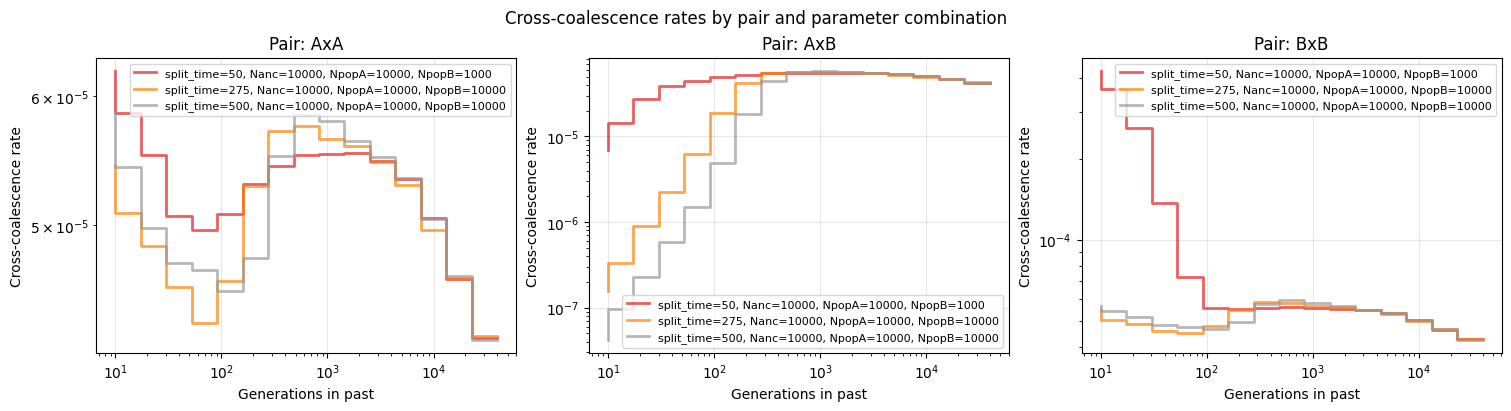

In [47]:
# Load pickle data and average within each group
groups = df.group_by("split_time", "Nanc", "NpopA", "NpopB").agg(pl.count()).sort("split_time")
print(groups)

group_data = {}
for row in groups.iter_rows(named=True):
    group_key = (row["split_time"], row["Nanc"], row["NpopA"], row["NpopB"])
    
    # Filter files for this group
    mask = (
        (df["split_time"] == row["split_time"]) &
        (df["Nanc"] == row["Nanc"]) &
        (df["NpopA"] == row["NpopA"]) &
        (df["NpopB"] == row["NpopB"])
    )
    group_files = df.filter(mask)["filename"].to_list()
    
    # Load and stack all rates from this group
    rates_list = []
    breaks = None
    names = None
    for f in group_files:
        data = pickle.load(open(f, "rb"))
        rates_list.append(data["rates"])
        if breaks is None:
            breaks = data["breaks"]
            names = data["names"]
    
    # Average across all files
    avg_rates = np.stack(rates_list).mean(axis=0)
    group_data[group_key] = {"rates": avg_rates, "breaks": breaks, "names": names}

print(f"Loaded {len(group_data)} groups")

# Get unique pairs (AxA, AxB, BxB) from names
# Assuming names like ['A', 'B']
names_sample = list(group_data.values())[0]["names"]
pairs = []
for j, p in enumerate(names_sample):
    for k, q in enumerate(names_sample):
        if j <= k:
            pairs.append((j, k, f"{p}x{q}"))

# Create plot with one subplot per pair
fig, axs = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4), constrained_layout=True)
if len(pairs) == 1:
    axs = [axs]

colors = plt.cm.Set1(np.linspace(0, 1, len(group_data)))

for pair_idx, (j, k, pair_name) in enumerate(pairs):
    ax = axs[pair_idx]
    
    for color_idx, (group_key, data) in enumerate(group_data.items()):
        split_time, Nanc, NpopA, NpopB = group_key
        breaks = data["breaks"][j, k]
        avg_rates = data["rates"][j, k]
        
        label = f"split_time={split_time}, Nanc={Nanc}, NpopA={NpopA}, NpopB={NpopB}"
        ax.step(breaks, avg_rates, color=colors[color_idx], linewidth=2, alpha=0.7, label=label)
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Generations in past")
    ax.set_ylabel("Cross-coalescence rate")
    ax.set_title(f"Pair: {pair_name}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Cross-coalescence rates by pair and parameter combination")
plt.savefig("cross_coalescence_rates_by_pair.png", dpi=150, bbox_inches="tight")
plt.show()
